# CAMELYON17 Dataset Audit

This notebook performs a reproducible structural and integrity audit of the
CAMELYON17 dataset used in the robustness study.

The audit covers:

- dataset size and structure
- official WILDS split assignment
- center and tumor-label distributions
- center–tumor association
- patient and slide structure
- metadata consistency
- image–metadata integrity

This notebook does not modify the official dataset splits or labels.

In [1]:
from pathlib import Path

REPO_ROOT = Path("/content/CAMELYON17-robustness")

print("Repo exists:", REPO_ROOT.exists())
print("Audit exists:", (REPO_ROOT / "src/data/audit.py").exists())
print("Splits exists:", (REPO_ROOT / "src/data/splits.py").exists())

Repo exists: False
Audit exists: False
Splits exists: False


In [2]:
from getpass import getpass
import subprocess

username = input("GitHub username: ")
token = getpass("GitHub Personal Access Token: ")

repo_url = "https://github.com/s-sana-sharifi/CAMELYON17-robustness.git"
repo_dir = "/content/CAMELYON17-robustness"

result = subprocess.run(
    [
        "git",
        "-c", f"http.extraHeader=Authorization: Basic "
               f"{__import__('base64').b64encode(f'{username}:{token}'.encode()).decode()}",
        "clone",
        repo_url,
        repo_dir,
    ],
    text=True,
    capture_output=True,
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"git clone failed with exit code {result.returncode}")

print("Clone successful:", repo_dir)

GitHub username: s-sana-sharifi
GitHub Personal Access Token: ··········

Cloning into '/content/CAMELYON17-robustness'...

Clone successful: /content/CAMELYON17-robustness


In [3]:
from pathlib import Path

repo_path = Path("/content/CAMELYON17-robustness")

print("Repo exists:", repo_path.exists())
print("audit.py:", (repo_path / "src/data/audit.py").exists())
print("splits.py:", (repo_path / "src/data/splits.py").exists())
print("notebook:", (repo_path / "notebooks/01_dataset_audit.ipynb").exists())

Repo exists: True
audit.py: True
splits.py: True
notebook: False


In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
from pathlib import Path

ARCHIVE = Path(
    "/content/drive/MyDrive/"
    "CAMELYON17-robustness/dataset/camelyon17_v1.0.tar"
)

print("Archive exists:", ARCHIVE.exists())

if ARCHIVE.exists():
    print(f"Archive size: {ARCHIVE.stat().st_size / (1024**3):.2f} GB")

Archive exists: True
Archive size: 10.68 GB


In [6]:
from pathlib import Path

repo_path = Path("/content/CAMELYON17-robustness")

print("Repo exists:", repo_path.exists())

if repo_path.exists():
    print("audit.py:", (repo_path / "src/data/audit.py").exists())
    print("splits.py:", (repo_path / "src/data/splits.py").exists())
    print(
        "notebook:",
        (repo_path / "notebooks/01_dataset_audit.ipynb").exists()
    )

Repo exists: True
audit.py: True
splits.py: True
notebook: False


In [7]:
from pathlib import Path
import tarfile

ARCHIVE = Path(
    "/content/drive/MyDrive/"
    "CAMELYON17-robustness/dataset/camelyon17_v1.0.tar"
)

EXTRACT_ROOT = Path("/content/wilds_data")

EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

print("Archive:", ARCHIVE)
print(f"Archive size: {ARCHIVE.stat().st_size / (1024**3):.2f} GB")
print("Extracting...")

with tarfile.open(ARCHIVE, "r") as tar:
    tar.extractall(EXTRACT_ROOT)

print("Extraction complete.")

Archive: /content/drive/MyDrive/CAMELYON17-robustness/dataset/camelyon17_v1.0.tar
Archive size: 10.68 GB
Extracting...


/tmp/ipykernel_4293/3827924951.py:18: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_ROOT)


Extraction complete.


In [8]:
from pathlib import Path

matches = list(Path("/content/wilds_data").rglob("metadata.csv"))

print(f"Found {len(matches)} metadata.csv file(s):")

for path in matches:
    print(path)

Found 1 metadata.csv file(s):
/content/wilds_data/camelyon17_v1.0/metadata.csv


In [9]:
METADATA_PATH = matches[0]
DATASET_ROOT = METADATA_PATH.parent
PATCHES_ROOT = DATASET_ROOT / "patches"

print("Dataset root:", DATASET_ROOT)
print("Metadata:", METADATA_PATH)
print("Patches:", PATCHES_ROOT)

print("\nMetadata exists:", METADATA_PATH.exists())
print("Patches exists:", PATCHES_ROOT.exists())

Dataset root: /content/wilds_data/camelyon17_v1.0
Metadata: /content/wilds_data/camelyon17_v1.0/metadata.csv
Patches: /content/wilds_data/camelyon17_v1.0/patches

Metadata exists: True
Patches exists: True


In [10]:
import sys
import os

sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

print("Repository:", Path.cwd())

Repository: /content/CAMELYON17-robustness


In [11]:
from src.data.audit import (
    load_metadata,
    summarize_dataset,
    summarize_splits,
    summarize_centers,
    summarize_labels,
    center_label_distribution,
    tumor_probability_by_center,
    patient_structure,
    slide_structure,
    check_metadata_consistency,
)

In [12]:
from src.data.splits import assign_official_split_ids

In [13]:
metadata = load_metadata(METADATA_PATH)

print(f"Loaded metadata with {len(metadata):,} rows.")

print("\nColumns:")
print(metadata.columns.tolist())

Loaded metadata with 455,954 rows.

Columns:
['Unnamed: 0', 'patient', 'node', 'x_coord', 'y_coord', 'tumor', 'slide', 'center', 'split']


In [14]:
dataset_summary = summarize_dataset(metadata)

for key, value in dataset_summary.items():
    print(f"{key}: {value:,}")

num_samples: 455,954
num_patients: 43
num_slides: 50
num_centers: 5


In [15]:
import pandas as pd

official_split = assign_official_split_ids(
    metadata["center"],
    metadata["split"],
)

print(pd.Series(official_split).value_counts().sort_index())

0    302436
1     33560
2     85054
3     34904
Name: count, dtype: int64


In [16]:
official_split = assign_official_split_ids(
    metadata["center"],
    metadata["split"],
)

metadata_audit = metadata.copy()
metadata_audit["official_split"] = official_split

In [17]:
OFFICIAL_SPLIT_NAMES = {
    0: "Train",
    1: "Validation (ID)",
    2: "Test (OOD)",
    3: "Validation (OOD)",
}

split_summary = (
    metadata_audit["official_split"]
    .value_counts()
    .sort_index()
    .rename_axis("split_id")
    .reset_index(name="num_samples")
)

split_summary["split"] = split_summary["split_id"].map(OFFICIAL_SPLIT_NAMES)
split_summary["proportion"] = (
    split_summary["num_samples"] / len(metadata_audit)
)

print(split_summary[
    ["split_id", "split", "num_samples", "proportion"]
].to_string(index=False))

 split_id            split  num_samples  proportion
        0            Train       302436    0.663304
        1  Validation (ID)        33560    0.073604
        2       Test (OOD)        85054    0.186541
        3 Validation (OOD)        34904    0.076552


In [18]:
center_summary = summarize_centers(metadata)

print(center_summary.to_string(index=False))

 center  num_samples  proportion
      0        59436    0.130355
      1        34904    0.076552
      2        85054    0.186541
      3       129838    0.284761
      4       146722    0.321791


In [19]:
label_summary = summarize_labels(metadata)

print(label_summary.to_string(index=False))

 tumor  num_samples  proportion
     0       227977         0.5
     1       227977         0.5


In [20]:
center_tumor = center_label_distribution(metadata)

print(center_tumor.to_string(index=False))

 center  tumor  num_samples  proportion_within_center
      0      0        29718                       0.5
      0      1        29718                       0.5
      1      0        17452                       0.5
      1      1        17452                       0.5
      2      0        42527                       0.5
      2      1        42527                       0.5
      3      0        64919                       0.5
      3      1        64919                       0.5
      4      0        73361                       0.5
      4      1        73361                       0.5


In [21]:
tumor_prob_by_center = tumor_probability_by_center(metadata)

print(tumor_prob_by_center.to_string(index=False))

 center  p_tumor_1
      0        0.5
      1        0.5
      2        0.5
      3        0.5
      4        0.5


In [22]:
patient_summary = patient_structure(metadata)

print(patient_summary.to_string(index=False))

 center  patient  num_samples  num_slides
      0        4         4316           1
      0        9         4597           1
      0       10         4046           1
      0       12        13637           1
      0       15        10554           2
      0       16         3427           1
      0       17        18859           3
      1       20         7449           2
      1       21         1705           1
      1       22        10404           1
      1       24         3854           2
      1       34         4971           1
      1       36         2659           1
      1       38         1275           1
      1       39         2587           1
      2       40         3810           1
      2       41         3694           1
      2       42         7210           1
      2       44         5288           1
      2       45         7727           1
      2       46         8149           2
      2       48         4556           1
      2       51        31878     

In [23]:
slide_summary = slide_structure(metadata)

print(slide_summary.to_string(index=False))

 center  patient  slide  num_samples  num_patients
      0        4      0         4316             1
      0        9      1         4597             1
      0       10      2         4046             1
      0       12      3        13637             1
      0       15      4         7294             1
      0       15      5         3260             1
      0       16      6         3427             1
      0       17      7         1596             1
      0       17      8        13455             1
      0       17      9         3808             1
      1       20     10         2078             1
      1       20     11         5371             1
      1       21     12         1705             1
      1       22     13        10404             1
      1       24     14          888             1
      1       24     15         2966             1
      1       34     16         4971             1
      1       36     17         2659             1
      1       38     18        

In [24]:
consistency_issues = check_metadata_consistency(metadata)

print("Consistency issues:")

if consistency_issues:
    for key, value in consistency_issues.items():
        print(f"- {key}: {value}")
else:
    print("No consistency issues found.")

Consistency issues:
No consistency issues found.


In [25]:
png_files = list(PATCHES_ROOT.rglob("*.png"))

print(f"PNG files found: {len(png_files):,}")
print(f"Metadata rows: {len(metadata):,}")

PNG files found: 455,954
Metadata rows: 455,954


In [26]:
for path in png_files[:5]:
    print(path)

/content/wilds_data/camelyon17_v1.0/patches/patient_073_node_1/patch_patient_073_node_1_x_19744_y_17568.png
/content/wilds_data/camelyon17_v1.0/patches/patient_073_node_1/patch_patient_073_node_1_x_20224_y_23424.png
/content/wilds_data/camelyon17_v1.0/patches/patient_073_node_1/patch_patient_073_node_1_x_13856_y_20832.png
/content/wilds_data/camelyon17_v1.0/patches/patient_073_node_1/patch_patient_073_node_1_x_5440_y_43712.png
/content/wilds_data/camelyon17_v1.0/patches/patient_073_node_1/patch_patient_073_node_1_x_1760_y_42368.png


In [27]:
import re

IMAGE_PATTERN = re.compile(
    r"patch_patient_(\d+)_node_(\d+)_x_(\d+)_y_(\d+)\.png$"
)

image_identities = []

for path in png_files:
    match = IMAGE_PATTERN.search(path.name)

    if match is None:
        raise ValueError(f"Unexpected filename format: {path}")

    patient, node, x_coord, y_coord = map(int, match.groups())

    image_identities.append(
        (patient, node, x_coord, y_coord)
    )

image_df = pd.DataFrame(
    image_identities,
    columns=["patient", "node", "x_coord", "y_coord"],
)

print(f"Parsed image identities: {len(image_df):,}")
print(f"Unique image identities: {len(image_df.drop_duplicates()):,}")

Parsed image identities: 455,954
Unique image identities: 455,954


In [28]:
metadata_identities = metadata[
    ["patient", "node", "x_coord", "y_coord"]
].copy()

print(
    f"Unique metadata identities: "
    f"{len(metadata_identities.drop_duplicates()):,}"
)

Unique metadata identities: 455,954


In [29]:
image_set = set(map(tuple, image_df.to_numpy()))
metadata_set = set(map(tuple, metadata_identities.to_numpy()))

images_missing_from_metadata = image_set - metadata_set
metadata_missing_from_images = metadata_set - image_set

print(
    "Images missing from metadata:",
    len(images_missing_from_metadata),
)

print(
    "Metadata entries missing from images:",
    len(metadata_missing_from_images),
)

print(
    "Exact identity match:",
    image_set == metadata_set,
)

Images missing from metadata: 0
Metadata entries missing from images: 0
Exact identity match: True


1. CAMELYON17 contains 455,954 image patches from 43 patients, 50 slides, and 5 centers.
2. The official WILDS split reconstruction gives 302,436 training samples, 33,560 ID validation samples, 34,904 OOD validation samples, and 85,054 OOD test samples.
3. Tumor labels are exactly balanced overall and within every center.
4. There is no aggregate center–tumor association in the metadata: P(tumor=1 | center) = 0.5 for every center.
5. Each patient belongs to one center, and each slide belongs to one patient and one center.
6. All 455,954 image patches have an exact metadata identity match.


In [30]:
print(metadata.columns.tolist())
print(metadata.head())

['Unnamed: 0', 'patient', 'node', 'x_coord', 'y_coord', 'tumor', 'slide', 'center', 'split']
   Unnamed: 0  patient  node  x_coord  y_coord  tumor  slide  center  split
0           0        4     4     3328    21792      1      0       0      0
1           1        4     4     3200    22272      1      0       0      0
2           2        4     4     3168    22272      1      0       0      0
3           3        4     4     3328    21760      1      0       0      0
4           4        4     4     3232    22240      1      0       0      0


In [31]:
patient_split = (
    metadata_audit
    .groupby("patient")["official_split"]
    .nunique()
)

print("Total patients:", patient_split.size)
print("Patients in exactly one split:", (patient_split == 1).sum())
print("Patients in multiple splits:", (patient_split > 1).sum())

print("\nNumber of splits per patient:")
print(patient_split.value_counts().sort_index())

Total patients: 43
Patients in exactly one split: 17
Patients in multiple splits: 26

Number of splits per patient:
official_split
1    17
2    26
Name: count, dtype: int64


In [32]:
multi_split_patients = patient_split[patient_split > 1].index

patient_split_details = (
    metadata_audit[
        metadata_audit["patient"].isin(multi_split_patients)
    ]
    [["patient", "center", "slide", "official_split"]]
    .drop_duplicates()
    .sort_values(["patient", "official_split", "slide"])
)

print(
    patient_split_details
    .to_string(index=False)
)

 patient  center  slide  official_split
       4       0      0               0
       4       0      0               1
       9       0      1               0
       9       0      1               1
      10       0      2               0
      10       0      2               1
      12       0      3               0
      12       0      3               1
      15       0      4               0
      15       0      5               0
      15       0      4               1
      15       0      5               1
      16       0      6               0
      16       0      6               1
      17       0      7               0
      17       0      8               0
      17       0      9               0
      17       0      7               1
      17       0      8               1
      17       0      9               1
      60       3     30               0
      60       3     30               1
      61       3     31               0
      61       3     31               1


In [33]:
slide_split = (
    metadata_audit
    .groupby("slide")["official_split"]
    .nunique()
)

print("Total slides:", slide_split.size)
print("Slides in exactly one split:", (slide_split == 1).sum())
print("Slides in multiple splits:", (slide_split > 1).sum())

print("\nNumber of splits per slide:")
print(slide_split.value_counts().sort_index())

Total slides: 50
Slides in exactly one split: 20
Slides in multiple splits: 30

Number of splits per slide:
official_split
1    20
2    30
Name: count, dtype: int64


In [34]:
patient_split_pairs = (
    metadata_audit[
        ["patient", "official_split"]
    ]
    .drop_duplicates()
    .sort_values(["patient", "official_split"])
)

print(
    pd.crosstab(
        patient_split_pairs["official_split"],
        columns="count"
    )
)

col_0           count
official_split       
0                  26
1                  26
2                   9
3                   8


In [35]:
patient_split_combinations = (
    metadata_audit
    .groupby("patient")["official_split"]
    .apply(lambda x: tuple(sorted(x.unique())))
)

print(
    patient_split_combinations
    .value_counts()
    .sort_index()
)

official_split
(0, 1)    26
(2,)       9
(3,)       8
Name: count, dtype: int64


In [36]:
slide_split_combinations = (
    metadata_audit
    .groupby("slide")["official_split"]
    .apply(lambda x: tuple(sorted(x.unique())))
)

print(
    slide_split_combinations
    .value_counts()
    .sort_index()
)

official_split
(0, 1)    30
(2,)      10
(3,)      10
Name: count, dtype: int64


In [37]:
patient_center_counts = (
    metadata_audit
    .groupby("center")["patient"]
    .nunique()
)

print(patient_center_counts)

center
0     7
1     8
2     9
3    10
4     9
Name: patient, dtype: int64


In [38]:
patient_counts_by_center = (
    metadata_audit
   .groupby(["center", "patient"])
    .size()
    .reset_index(name="num_patches")
)

print(patient_counts_by_center)

    center  patient  num_patches
0        0        4         4316
1        0        9         4597
2        0       10         4046
3        0       12        13637
4        0       15        10554
5        0       16         3427
6        0       17        18859
7        1       20         7449
8        1       21         1705
9        1       22        10404
10       1       24         3854
11       1       34         4971
12       1       36         2659
13       1       38         1275
14       1       39         2587
15       2       40         3810
16       2       41         3694
17       2       42         7210
18       2       44         5288
19       2       45         7727
20       2       46         8149
21       2       48         4556
22       2       51        31878
23       2       52        12742
24       3       60        10623
25       3       61         3466
26       3       62         8831
27       3       64         4019
28       3       66         3950
29       3

In [39]:
patient_patch_stats = (
    metadata_audit
    .groupby(["center", "patient"])
    .size()
    .reset_index(name="num_patches")
)

print(patient_patch_stats.groupby("center")["num_patches"].describe())

        count          mean           std     min     25%      50%      75%  \
center                                                                        
0         7.0   8490.857143   6003.175422  3427.0  4181.0   4597.0  12095.5   
1         8.0   4363.000000   3146.524659  1275.0  2366.5   3256.5   5590.5   
2         9.0   9450.444444   8872.330530  3694.0  4556.0   7210.0   8149.0   
3        10.0  12983.800000  16328.590113  3466.0  4349.0   7460.0  10651.5   
4         9.0  16302.444444  17318.212250  4914.0  7395.0  11526.0  15806.0   

            max  
center           
0       18859.0  
1       10404.0  
2       31878.0  
3       57375.0  
4       61110.0  


In [40]:
print(
    patient_patch_stats
    .sort_values("num_patches")
    .to_string(index=False)
)

 center  patient  num_patches
      1       38         1275
      1       21         1705
      1       39         2587
      1       36         2659
      0       16         3427
      3       61         3466
      2       41         3694
      2       40         3810
      1       24         3854
      3       66         3950
      3       64         4019
      0       10         4046
      0        4         4316
      2       48         4556
      0        9         4597
      4       89         4914
      1       34         4971
      2       44         5288
      3       72         5339
      3       67         6089
      4       88         6956
      2       42         7210
      4       80         7395
      1       20         7449
      2       45         7727
      4       87         7958
      2       46         8149
      3       62         8831
      1       22        10404
      0       15        10554
      3       60        10623
      3       68        10661
      4   

In [41]:
%cd /content/CAMELYON17-robustness
!git status

/content
On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [42]:
%cd /content/CAMELYON17-robustness

!ls src
!ls src/data

/content
data  models
audit.py       dataset.py   __pycache__  splits.py
camelyon17.py  __init__.py  sampling.py


In [43]:
import sys
sys.path.insert(0, "/content/CAMELYON17-robustness")

from src.data.sampling import sample_patches_by_patient

print("Import successful")

Import successful


In [44]:
%cd /content/CAMELYON17-robustness

from pathlib import Path

Path("pyproject.toml").write_text(
    """[tool.pytest.ini_options]
pythonpath = ["."]
testpaths = ["tests"]
""",
    encoding="utf-8",
)

/content


67

In [45]:
!pytest tests/test_sampling.py -v

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/CAMELYON17-robustness
configfile: pyproject.toml
plugins: langsmith-0.12.1, anyio-4.14.2, typeguard-4.6.0
collected 0 items / 1 error                                                    

==================================== ERRORS ====================================
___________________ ERROR collecting tests/test_sampling.py ____________________
/usr/local/lib/python3.13/dist-packages/_pytest/python.py:498: in importtestmodule
    mod = import_path(
/usr/local/lib/python3.13/dist-packages/_pytest/pathlib.py:587: in import_path
    importlib.import_module(module_name)
/usr/lib/python3.13/importlib/__init__.py:88: in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
<frozen importlib._bootstrap>:

In [46]:
!gh --version

gh version 2.101.0 (2026-09-15)
https://github.com/cli/cli/releases/tag/v2.101.0


In [47]:
!gh auth logout --hostname github.com 2>/dev/null || true

In [48]:
!git config --global credential.helper store

In [49]:
%cd /content/CAMELYON17-robustness
!git remote -v

/content
origin	https://github.com/s-sana-sharifi/CAMELYON17-robustness.git (fetch)
origin	https://github.com/s-sana-sharifi/CAMELYON17-robustness.git (push)


In [50]:
!ls -l ~/.ssh/github_colab*

ls: cannot access '/root/.ssh/github_colab*': No such file or directory


In [51]:
!cat ~/.ssh/github_colab.pub

cat: /root/.ssh/github_colab.pub: No such file or directory


In [52]:
!ssh -T -i ~/.ssh/github_colab -o StrictHostKeyChecking=accept-new git@github.com

git@github.com: Permission denied (publickey).


In [53]:
!git config --global core.sshCommand "ssh -i ~/.ssh/github_colab -o IdentitiesOnly=yes"

In [54]:
%cd /content/CAMELYON17-robustness
!git remote set-url origin git@github.com:s-sana-sharifi/CAMELYON17-robustness.git
!git remote -v

/content
origin	git@github.com:s-sana-sharifi/CAMELYON17-robustness.git (fetch)
origin	git@github.com:s-sana-sharifi/CAMELYON17-robustness.git (push)


In [55]:
%cd /content/CAMELYON17-robustness
!git pull origin main

/content
git@github.com: Permission denied (publickey).
fatal: Could not read from remote repository.

Please make sure you have the correct access rights
and the repository exists.


In [56]:
%%writefile tests/test_sampling.py
import numpy as np
import pandas as pd
import pytest

from src.data.sampling import sample_patches_by_patient


def make_metadata(patients: dict[int, int]) -> pd.DataFrame:
    rows = []

    for patient, n_patches in patients.items():
        for patch_id in range(n_patches):
            rows.append(
                {
                    "patient": patient,
                    "patch_id": f"{patient}_{patch_id}",
                }
            )

    return pd.DataFrame(rows)


def test_samples_exact_number_per_patient():
    metadata = make_metadata({1: 10, 2: 20, 3: 30})

    sampled = sample_patches_by_patient(
        metadata,
        n_samples=5,
        seed=42,
    )

    counts = sampled["patient"].value_counts().sort_index()

    expected = pd.Series({1: 5, 2: 5, 3: 5})
    expected.index.name = "patient"

    pd.testing.assert_series_equal(counts, expected)


def test_samples_without_replacement():
    metadata = make_metadata({1: 10, 2: 10})

    sampled = sample_patches_by_patient(
        metadata,
        n_samples=5,
        seed=42,
    )

    assert sampled.index.is_unique


def test_sampling_is_reproducible():
    metadata = make_metadata({1: 10, 2: 10, 3: 10})

    sampled_1 = sample_patches_by_patient(
        metadata,
        n_samples=5,
        seed=42,
    )

    sampled_2 = sample_patches_by_patient(
        metadata,
        n_samples=5,
        seed=42,
    )

    pd.testing.assert_frame_equal(sampled_1, sampled_2)


def test_different_seeds_can_produce_different_samples():
    metadata = make_metadata({1: 20, 2: 20})

    sampled_1 = sample_patches_by_patient(
        metadata,
        n_samples=5,
        seed=42,
    )

    sampled_2 = sample_patches_by_patient(
        metadata,
        n_samples=5,
        seed=123,
    )

    assert not sampled_1.index.equals(sampled_2.index)


def test_patient_identity_is_preserved():
    metadata = make_metadata({1: 10, 2: 10, 3: 10})

    sampled = sample_patches_by_patient(
        metadata,
        n_samples=5,
        seed=42,
    )

    assert set(sampled["patient"]) == {1, 2, 3}


def test_sampled_index_is_unique():
    metadata = make_metadata({1: 10, 2: 10, 3: 10})

    sampled = sample_patches_by_patient(
        metadata,
        n_samples=5,
        seed=42,
    )

    assert sampled.index.is_unique


def test_insufficient_patches_raises_value_error():
    metadata = make_metadata({1: 10, 2: 3})

    with pytest.raises(ValueError):
        sample_patches_by_patient(
            metadata,
            n_samples=5,
            seed=42,
        )


def test_invalid_n_samples_raises_value_error():
    metadata = make_metadata({1: 10})

    with pytest.raises(ValueError):
        sample_patches_by_patient(
            metadata,
            n_samples=0,
            seed=42,
        )


def test_missing_patient_column_raises_key_error():
    metadata = pd.DataFrame(
        {
            "patch_id": ["a", "b", "c"],
        }
    )

    with pytest.raises(KeyError):
        sample_patches_by_patient(
            metadata,
            n_samples=1,
            seed=42,
        )


def test_seed_must_be_integer():
    metadata = make_metadata({1: 10})

    with pytest.raises(TypeError):
        sample_patches_by_patient(
            metadata,
            n_samples=5,
            seed="42",
        )

Overwriting tests/test_sampling.py


In [57]:
%cd /content/CAMELYON17-robustness
!sed -i 's/pd.testing.assert_series_equal(counts, expected)/pd.testing.assert_series_equal(counts, expected, check_names=False)/' tests/test_sampling.py

/content


In [58]:
!grep -A2 "assert_series_equal" tests/test_sampling.py

    pd.testing.assert_series_equal(counts, expected, check_names=False)




In [59]:
!pytest tests/test_sampling.py -v

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/CAMELYON17-robustness
configfile: pyproject.toml
plugins: langsmith-0.12.1, anyio-4.14.2, typeguard-4.6.0
collected 10 items                                                             

tests/test_sampling.py::test_samples_exact_number_per_patient PASSED     [ 10%]
tests/test_sampling.py::test_samples_without_replacement PASSED          [ 20%]
tests/test_sampling.py::test_sampling_is_reproducible PASSED             [ 30%]
tests/test_sampling.py::test_different_seeds_can_produce_different_samples PASSED [ 40%]
tests/test_sampling.py::test_patient_identity_is_preserved PASSED        [ 50%]
tests/test_sampling.py::test_sampled_index_is_unique PASSED              [ 60%]
tests/test_sampling.py::test_insufficient_patches_raises_value_error PASSED [ 70%]
tests/test_sampling.py::test_invalid_

In [60]:
!pytest tests/test_sampling.py tests/test_splits.py -v

============================= test session starts ==============================
platform linux -- Python 3.13.15, pytest-8.4.2, pluggy-1.6.0 -- /usr/bin/python3
cachedir: .pytest_cache
rootdir: /content/CAMELYON17-robustness
configfile: pyproject.toml
plugins: langsmith-0.12.1, anyio-4.14.2, typeguard-4.6.0
collected 20 items                                                             

tests/test_sampling.py::test_samples_exact_number_per_patient PASSED     [  5%]
tests/test_sampling.py::test_samples_without_replacement PASSED          [ 10%]
tests/test_sampling.py::test_sampling_is_reproducible PASSED             [ 15%]
tests/test_sampling.py::test_different_seeds_can_produce_different_samples PASSED [ 20%]
tests/test_sampling.py::test_patient_identity_is_preserved PASSED        [ 25%]
tests/test_sampling.py::test_sampled_index_is_unique PASSED              [ 30%]
tests/test_sampling.py::test_insufficient_patches_raises_value_error PASSED [ 35%]
tests/test_sampling.py::test_invalid_

In [61]:
from src.models.probes import HospitalProbe

model = HospitalProbe(num_centers=5, pretrained=False)
print(model)

HospitalProbe(
  (encoder): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [63]:
from pathlib import Path
import tarfile
import pandas as pd

TAR_PATH = Path(
    "/content/drive/MyDrive/CAMELYON17-robustness/"
    "dataset/camelyon17_v1.0.tar"
)

if not TAR_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {TAR_PATH}")

print(f"Archive: {TAR_PATH}")
print(f"Size: {TAR_PATH.stat().st_size / 1024**3:.2f} GB")

with tarfile.open(TAR_PATH, "r") as tar:
    with tar.extractfile("camelyon17_v1.0/metadata.csv") as f:
        metadata = pd.read_csv(f)

print("Metadata shape:", metadata.shape)
print(metadata.head())

Archive: /content/drive/MyDrive/CAMELYON17-robustness/dataset/camelyon17_v1.0.tar
Size: 10.68 GB
Metadata shape: (455954, 9)
   Unnamed: 0  patient  node  x_coord  y_coord  tumor  slide  center  split
0           0        4     4     3328    21792      1      0       0      0
1           1        4     4     3200    22272      1      0       0      0
2           2        4     4     3168    22272      1      0       0      0
3           3        4     4     3328    21760      1      0       0      0
4           4        4     4     3232    22240      1      0       0      0


Reading:
camelyon17_v1.0/patches/patient_004_node_4/patch_patient_004_node_4_x_3328_y_21792.png
Image size: (96, 96)
Image mode: RGB


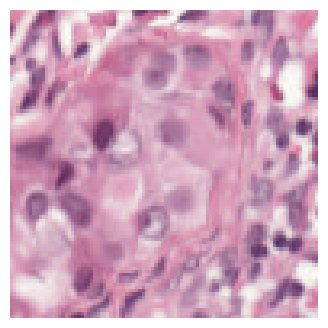

In [65]:
import tarfile
from PIL import Image
import matplotlib.pyplot as plt

row = metadata.iloc[0]

patient = str(int(row["patient"])).zfill(3)
node = int(row["node"])
x = int(row["x_coord"])
y = int(row["y_coord"])

member_name = (
    f"camelyon17_v1.0/patches/"
    f"patient_{patient}_node_{node}/"
    f"patch_patient_{patient}_node_{node}_x_{x}_y_{y}.png"
)

print("Reading:")
print(member_name)

with tarfile.open(TAR_PATH, "r") as tar:
    with tar.extractfile(member_name) as f:
        image = Image.open(f).convert("RGB")
        image.load()

print("Image size:", image.size)
print("Image mode:", image.mode)

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off");